Задание 1 (4 балла)
Обучите 2 модели похожую по архитектуре на модель из ULMFit для задачи классификации текста (датасет - lenta_40k ) В моделях должно быть как минимум два рекуррентных слоя, а финальный вектор для классификации составляться из последнего состояния RNN (так делалось в семинаре), а также AveragePooling и MaxPooling из всех векторов последовательности (конкатенируйте последнее состояния и результаты пулинга). В первой модели используйте обычные слои, а во второй Bidirectional. Рассчитайте по классовую точность/полноту/f-меру для каждой из модели (результаты не должны быть совсем близкие к нулю после обучения на хотя бы нескольких эпохах).


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data

In [6]:
import pandas as pd
import numpy as np
from string import punctuation
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
%matplotlib inline

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
data = pd.read_csv('/content/drive/MyDrive/lenta_40k.csv')

In [28]:
data.dropna(subset=['topic', 'text'], inplace=True)

In [29]:
data

,text,topic
0,Россия должна сотрудничать с Всемирным антидоп...,Спорт
1,Уголовный суд Кувейта 28 июня освободил под за...,Мир
2,Французский журнал Charlie Hebdo опубликовал н...,Интернет и СМИ
3,В Петербурге в доме № 53 по улице Лени Голиков...,Россия
4,"В московском аэропорту ""Домодедово"" задержан г...",Россия
...,...,...
44351,Российский Минфин может пересмотреть минимальн...,Экономика
44352,Сотрудники Службы безопасности Украины (СБУ) с...,Бывший СССР
44353,Америке следует задуматься над поставками на У...,Силовые структуры
44354,"Опознаны тела 71 человека, погибшего в результ...",Мир


In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
label_encoder = LabelEncoder()
data['topic'] = label_encoder.fit_transform(data['topic'])

NUM_CLASSES = len(label_encoder.classes_)
NUM_CLASSES, label_encoder.classes_


(19,
 array(['69-я параллель', 'Библиотека', 'Бизнес', 'Бывший СССР', 'Дом',
        'Из жизни', 'Интернет и СМИ', 'Крым', 'Культпросвет ', 'Культура',
        'Легпром', 'Мир', 'Наука и техника', 'Путешествия', 'Россия',
        'Силовые структуры', 'Спорт', 'Ценности', 'Экономика'],
       dtype=object))

In [32]:
train_df, test_df = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data['topic']
)


In [33]:
def preprocess(text):
    tokens = text.lower().split()
    tokens = [token.strip(punctuation) for token in tokens]
    return tokens

In [34]:
from collections import Counter

counter = Counter()

for text in data.text:
    counter.update(preprocess(text))

len(counter)


354611

In [35]:
MAX_VOCAB_SIZE = 25000

PAD_IDX = 0
UNK_IDX = 1

vocab = {
    "<pad>": PAD_IDX,
    "<unk>": UNK_IDX
}

for i, (word, _) in enumerate(
    counter.most_common(MAX_VOCAB_SIZE - 2),
    start=2
):
    vocab[word] = i


In [36]:
len(vocab)

25000

In [37]:
word2id = vocab
id2word = {i: w for w, i in vocab.items()}

In [38]:
MAX_LEN = 200

def encode(tokens):
    ids = [word2id.get(t, UNK_IDX) for t in tokens]
    return ids[:MAX_LEN]

In [39]:
from torch.utils.data import Dataset, DataLoader

In [40]:
class LentaDataset(Dataset):
    def __init__(self, df):
        self.texts = df['text'].tolist()
        self.labels = df['topic'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tokens = preprocess(self.texts[idx])
        x = encode(tokens)
        y = self.labels[idx]
        return torch.tensor(x), torch.tensor(y, dtype=torch.long)


In [41]:
def collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])

    max_len = max(lengths)
    padded = torch.full(
        (len(texts), max_len),
        PAD_IDX,
        dtype=torch.long
    )

    for i, t in enumerate(texts):
        padded[i, :len(t)] = t

    return padded, torch.tensor(labels), lengths


In [42]:
train_loader = DataLoader(
    LentaDataset(train_df),
    batch_size=512,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    LentaDataset(test_df),
    batch_size=512,
    shuffle=False,
    collate_fn=collate_fn
)

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [44]:
from sklearn.metrics import f1_score
from tqdm.notebook import tqdm

In [45]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x, y, lengths in loader:
        x = x.to(device)
        y = y.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [46]:
def evaluate_metrics(model, loader, target_names):
    model.eval()
    preds, golds = [], []

    with torch.no_grad():
        for x, y, lengths in loader:
            x = x.to(device)
            lengths = lengths.to(device)

            logits = model(x, lengths)
            batch_preds = torch.argmax(logits, dim=1).cpu().tolist()
            batch_golds = y.tolist()

            preds.extend(batch_preds)
            golds.extend(batch_golds)
    all_label_ids = list(range(len(target_names)))

    report_dict = classification_report(
        golds,
        preds,
        labels=all_label_ids,
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )

    report_str = classification_report(
        golds,
        preds,
        labels=all_label_ids,
        target_names=target_names,
        zero_division=0
    )

    return report_dict, report_str

In [47]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, emb_dim, padding_idx=pad_idx
        )

        self.rnn = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_dim * 3, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        out, (h, _) = self.rnn(packed)

        out, _ = nn.utils.rnn.pad_packed_sequence(
            out, batch_first=True
        )

        last = h[-1]

        mask = (x != PAD_IDX).unsqueeze(-1)
        out = out * mask

        avg_pool = out.sum(dim=1) / mask.sum(dim=1)
        max_pool, _ = out.max(dim=1)

        features = torch.cat([last, avg_pool, max_pool], dim=1)
        return self.fc(features)


In [48]:
model = RNNClassifier(
    vocab_size=len(vocab),
    emb_dim=100,
    hidden_dim=128,
    num_classes=len(label_encoder.classes_),
    pad_idx=PAD_IDX
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


In [67]:
history = {
    'loss': [],
    'precision': [],
    'recall': [],
    'f1': []
}

epochs = 10

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    report, _ = evaluate_metrics(model, test_loader, label_encoder.classes_)
    macro_metrics = report['macro avg']

    history['loss'].append(train_loss)
    history['precision'].append(macro_metrics['precision'])
    history['recall'].append(macro_metrics['recall'])
    history['f1'].append(macro_metrics['f1-score'])

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {train_loss:.4f} | "
          f"F1-score: {macro_metrics['f1-score']:.4f}")

print("\nОтчет по классам:")
_, final_report_str = evaluate_metrics(model, test_loader, label_encoder.classes_)
print(final_report_str)

Epoch 1/10 | Loss: 1.5186 | F1-score: 0.2275
Epoch 2/10 | Loss: 1.2865 | F1-score: 0.2788
Epoch 3/10 | Loss: 1.1296 | F1-score: 0.3109
Epoch 4/10 | Loss: 0.9950 | F1-score: 0.3368
Epoch 5/10 | Loss: 0.8901 | F1-score: 0.3663
Epoch 6/10 | Loss: 0.7964 | F1-score: 0.3819
Epoch 7/10 | Loss: 0.7222 | F1-score: 0.3810
Epoch 8/10 | Loss: 0.6459 | F1-score: 0.3926
Epoch 9/10 | Loss: 0.5731 | F1-score: 0.4129
Epoch 10/10 | Loss: 0.5083 | F1-score: 0.4120

Отчет по классам:
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00        16
       Библиотека       0.00      0.00      0.00         0
           Бизнес       0.26      0.13      0.17        87
      Бывший СССР       0.76      0.67      0.71       636
              Дом       0.64      0.67      0.66       263
         Из жизни       0.41      0.35      0.37       336
   Интернет и СМИ       0.44      0.44      0.44       529
             Крым       0.00      0.00      0.00         

In [37]:
class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, emb_dim, padding_idx=pad_idx
        )

        self.rnn = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_dim * 6, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        out, (h, _) = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            out, batch_first=True
        )

        last = torch.cat([h[-2], h[-1]], dim=1)

        mask = (x != PAD_IDX).unsqueeze(-1)
        out = out * mask

        avg_pool = out.sum(dim=1) / mask.sum(dim=1)
        max_pool, _ = out.max(dim=1)

        features = torch.cat([last, avg_pool, max_pool], dim=1)
        return self.fc(features)


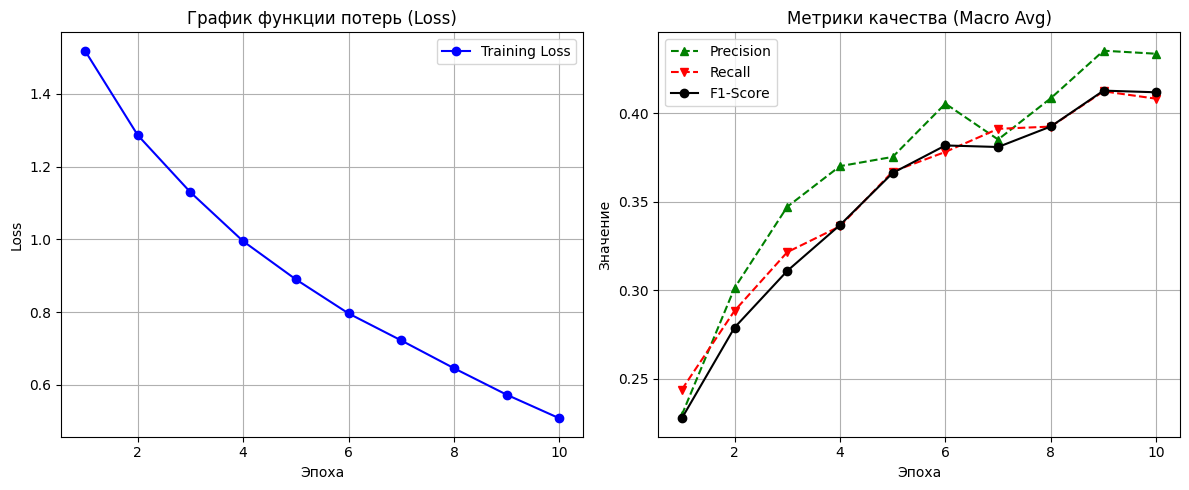

In [68]:

def plot_history(history):
    epochs_range = range(1, len(history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['loss'], 'b-o', label='Training Loss')
    plt.title('График функции потерь (Loss)')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['precision'], 'g--^', label='Precision')
    plt.plot(epochs_range, history['recall'], 'r--v', label='Recall')
    plt.plot(epochs_range, history['f1'], 'k-o', label='F1-Score')
    plt.title('Метрики качества (Macro Avg)')
    plt.xlabel('Эпоха')
    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [69]:
bi_model = BiRNNClassifier(
    vocab_size=len(vocab),
    emb_dim=100,
    hidden_dim=128,
    num_classes=len(label_encoder.classes_),
    pad_idx=PAD_IDX
).to(device)

optimizer = optim.Adam(bi_model.parameters(), lr=1e-3)

In [70]:
history_1 = {
    'loss': [],
    'precision': [],
    'recall': [],
    'f1': []
}

epochs = 10

for epoch in range(epochs):
    train_loss = train_epoch(bi_model, train_loader, optimizer, criterion)
    report, _ = evaluate_metrics(bi_model, test_loader, label_encoder.classes_)

    macro_metrics = report['macro avg']

    history_1['loss'].append(train_loss)
    history_1['precision'].append(macro_metrics['precision'])
    history_1['recall'].append(macro_metrics['recall'])
    history_1['f1'].append(macro_metrics['f1-score'])

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {train_loss:.4f} | "
          f"F1-score: {macro_metrics['f1-score']:.4f}")

print("\nОтчет по классам:")
_, final_report_str = evaluate_metrics(model, test_loader, label_encoder.classes_)
print(final_report_str)

Epoch 1/10 | Loss: 2.2279 | F1-score: 0.1214
Epoch 2/10 | Loss: 1.6271 | F1-score: 0.2409
Epoch 3/10 | Loss: 1.2303 | F1-score: 0.3090
Epoch 4/10 | Loss: 1.0156 | F1-score: 0.3500
Epoch 5/10 | Loss: 0.8687 | F1-score: 0.3860
Epoch 6/10 | Loss: 0.7313 | F1-score: 0.4092
Epoch 7/10 | Loss: 0.6208 | F1-score: 0.4318
Epoch 8/10 | Loss: 0.5150 | F1-score: 0.4524
Epoch 9/10 | Loss: 0.4173 | F1-score: 0.4528
Epoch 10/10 | Loss: 0.3483 | F1-score: 0.4481

Отчет по классам:
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00        16
       Библиотека       0.00      0.00      0.00         0
           Бизнес       0.26      0.13      0.17        87
      Бывший СССР       0.76      0.67      0.71       636
              Дом       0.64      0.67      0.66       263
         Из жизни       0.41      0.35      0.37       336
   Интернет и СМИ       0.44      0.44      0.44       529
             Крым       0.00      0.00      0.00         

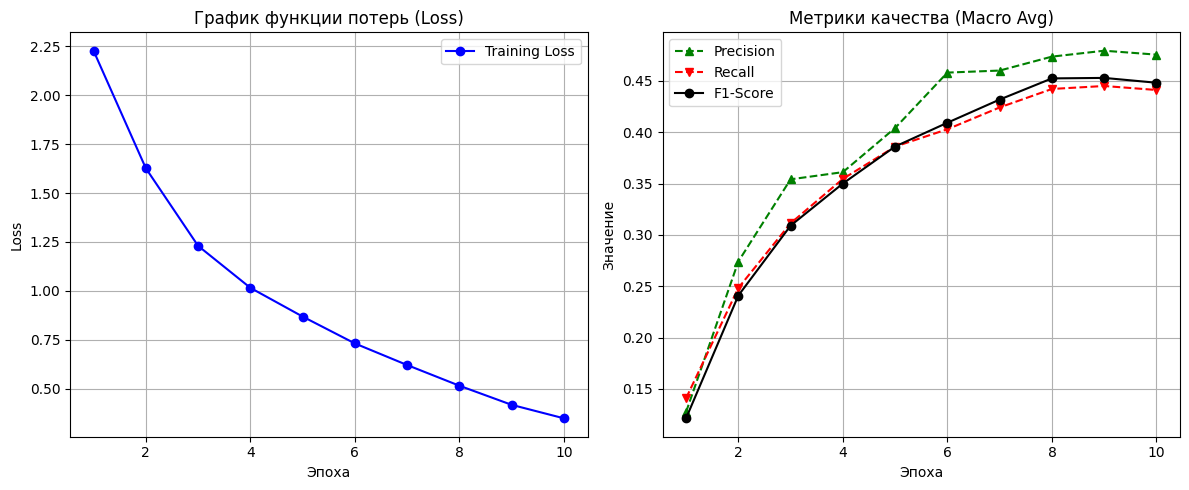

In [71]:
plot_history(history_1)

На данных википедии (wikiann) обучите и сравните 3 модели:

модель в которой как минимум два рекуррентных слоя, причем один из них GRU, а другой LSTM
модель в которой как минимум 3 рекуррентных слоя идут друг за другом и при этом 2-ой и 3-й слои еще имеют residual connection к изначальным эмбедингам. Для того, чтобы сделать residual connection вам нужно будет использовать одинаковую размерность эмбедингов и количество unit'ов в RNN слоях, чтобы их можно было просуммировать
модель в которой будут и рекуррентные и сверточные слои (как минимум 2 rnn и как минимум 2 cnn слоя). В cnn слоях будьте аккуратны с укорачиванием последовательности и используйте паддинг
Сравните качество по метрикам (точность/полнота/f-мера). Также придумайте несколько сложных примеров и проверьте, какие сущности определяет каждая из моделей.

In [1]:
from datasets import load_dataset

In [2]:
dataset = load_dataset("unimelb-nlp/wikiann", 'ru')
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ru/validation-00000-of-00001.parquet:   0%|          | 0.00/809k [00:00<?, ?B/s]

ru/test-00000-of-00001.parquet:   0%|          | 0.00/816k [00:00<?, ?B/s]

ru/train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
})

In [10]:
vocab = Counter()
for sent in dataset['train']['tokens']:
    vocab.update([x.lower() for x in sent])

word2id = {'PAD': 0, 'UNK': 1}
for word in vocab:
    word2id[word] = len(word2id)

len(word2id)

36017

In [11]:
def encode_sentences(sentences, word2id):
    return [[word2id.get(w.lower(), 1) for w in sent] for sent in sentences]

def pad_sequences(sequences, max_len, pad_value=0):
    return np.array([seq[:max_len] + [pad_value] * max(0, max_len - len(seq)) for seq in sequences])

X_train = encode_sentences(dataset['train']['tokens'], word2id)
X_test = encode_sentences(dataset['test']['tokens'], word2id)

MAX_LEN = max(len(x) for x in X_train)
X_train = pad_sequences(X_train, MAX_LEN)
X_test = pad_sequences(X_test, MAX_LEN)

In [12]:
id2label = {0: "O", 1: "B-PER", 2: "I-PER", 3: "B-ORG", 4: "I-ORG", 5: "B-LOC", 6: "I-LOC", 7: "PAD"}
label2id = {v: k for k, v in id2label.items()}

# PAD индекс = 7 для ignore_index в CrossEntropyLoss
y_train = pad_sequences(dataset['train']['ner_tags'], MAX_LEN, pad_value=7)
y_test = pad_sequences(dataset['test']['ner_tags'], MAX_LEN, pad_value=7)

X_train.shape, y_train.shape

((20000, 54), (20000, 54))

In [13]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [18]:
from sklearn.metrics import classification_report

In [14]:
X_train_t = torch.LongTensor(X_train)
X_test_t = torch.LongTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)

In [15]:
class ModelMixRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.gru = nn.GRU(hidden_dim * 2, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)
        gru_out, _ = self.gru(lstm_out)
        logits = self.fc(gru_out)
        return logits.permute(0, 2, 1)

In [16]:
class ModelResidualRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes):
        super().__init__()
        assert emb_dim == hidden_dim, "размерности должны совпадать"

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.rnn1 = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.rnn2 = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.rnn3 = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out1, _ = self.rnn1(emb)
        out2_raw, _ = self.rnn2(out1)
        out2 = out2_raw + emb
        out3_raw, _ = self.rnn3(out2)
        out3 = out3_raw + emb

        logits = self.fc(out3)
        return logits.permute(0, 2, 1)

In [17]:
class ModelCNNRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.cnn1 = nn.Conv1d(in_channels=emb_dim, out_channels=emb_dim, kernel_size=3, padding=1)
        self.cnn2 = nn.Conv1d(in_channels=emb_dim, out_channels=emb_dim, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.rnn1 = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.rnn2 = nn.LSTM(hidden_dim*2, hidden_dim, batch_first=True, bidirectional=True)

        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        cnn_in = emb.permute(0, 2, 1)

        c1 = self.relu(self.cnn1(cnn_in))
        c1 = self.dropout(c1)
        c2 = self.relu(self.cnn2(c1))
        c2 = self.dropout(c2)

        rnn_in = c2.permute(0, 2, 1)

        r1, _ = self.rnn1(rnn_in)
        r2, _ = self.rnn2(r1)

        logits = self.fc(r2)
        return logits.permute(0, 2, 1)

In [19]:
TARGET_NAMES = [id2label[i] for i in range(7)]
TARGET_LABELS = [i for i in range(7)]
TAG_PAD_IDX = 7

In [20]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)

        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_metrics(model, loader):
    model.eval()
    preds, golds = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            batch_preds = torch.argmax(logits, dim=1)

            mask = (y != TAG_PAD_IDX)

            valid_preds = batch_preds[mask].cpu().numpy()
            valid_golds = y[mask].cpu().numpy()

            preds.extend(valid_preds)
            golds.extend(valid_golds)

    report = classification_report(
        golds,
        preds,
        labels=TARGET_LABELS,
        target_names=TARGET_NAMES,
        zero_division=0,
        output_dict=True
    )

    report_str = classification_report(
        golds,
        preds,
        labels=TARGET_LABELS,
        target_names=TARGET_NAMES,
        zero_division=0
    )

    return report, report_str

In [22]:
VOCAB_SIZE = len(word2id)
NUM_CLASSES = len(id2label)
EMBED_DIM = 128
HIDDEN_DIM = 128


 Training Mix RNN
Epoch 1/10 | Loss: 1.0450 | Macro F1: 0.6365
Epoch 2/10 | Loss: 0.5613 | Macro F1: 0.7391
Epoch 3/10 | Loss: 0.4126 | Macro F1: 0.7579
Epoch 4/10 | Loss: 0.3161 | Macro F1: 0.7800
Epoch 5/10 | Loss: 0.2284 | Macro F1: 0.7812
Epoch 6/10 | Loss: 0.1574 | Macro F1: 0.7630
Epoch 7/10 | Loss: 0.1028 | Macro F1: 0.7811
Epoch 8/10 | Loss: 0.0671 | Macro F1: 0.7618
Epoch 9/10 | Loss: 0.0415 | Macro F1: 0.7906
Epoch 10/10 | Loss: 0.0270 | Macro F1: 0.7604

 Training Residual RNN
Epoch 1/10 | Loss: 1.3380 | Macro F1: 0.3405
Epoch 2/10 | Loss: 0.9383 | Macro F1: 0.4826
Epoch 3/10 | Loss: 0.7799 | Macro F1: 0.5562
Epoch 4/10 | Loss: 0.6530 | Macro F1: 0.6037
Epoch 5/10 | Loss: 0.5462 | Macro F1: 0.6297
Epoch 6/10 | Loss: 0.4576 | Macro F1: 0.6486
Epoch 7/10 | Loss: 0.3837 | Macro F1: 0.6589
Epoch 8/10 | Loss: 0.3151 | Macro F1: 0.6691
Epoch 9/10 | Loss: 0.2591 | Macro F1: 0.6782
Epoch 10/10 | Loss: 0.2149 | Macro F1: 0.6880

 Training CNN + RNN
Epoch 1/10 | Loss: 1.2516 | Macro 

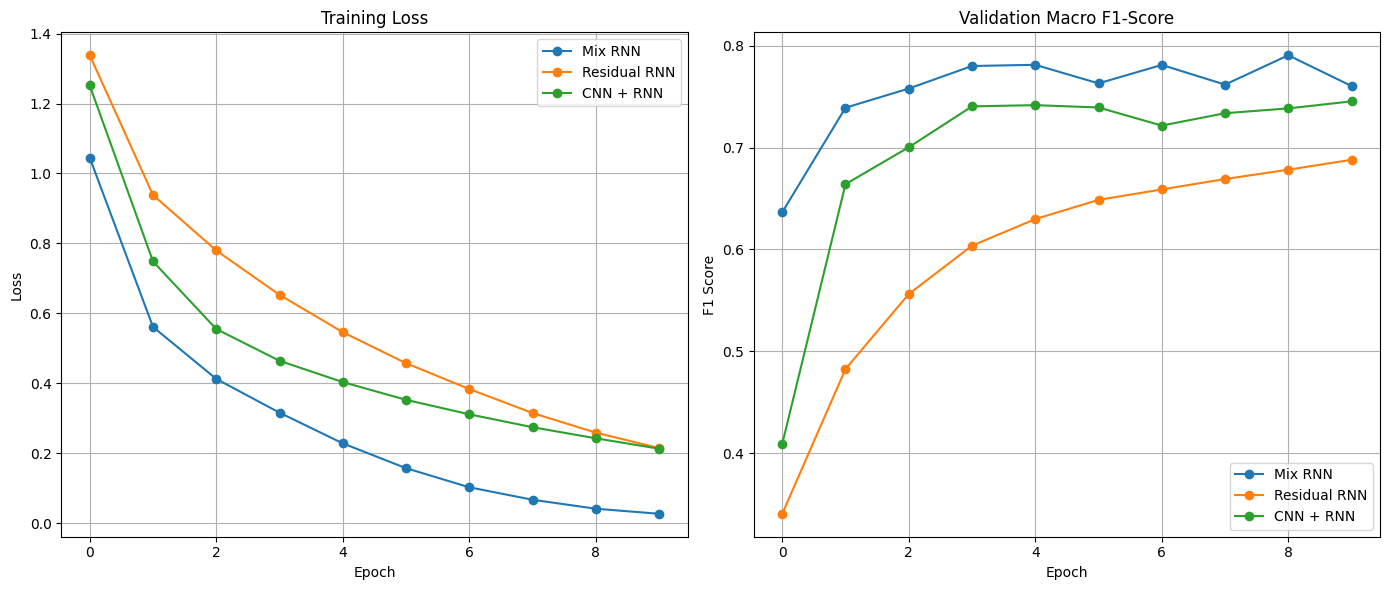


FINAL REPORTS (TEST SET)

MODEL: Mix RNN
              precision    recall  f1-score   support

           O       0.95      0.90      0.92     40480
       B-PER       0.52      0.91      0.67      3543
       I-PER       0.65      0.96      0.77      7544
       B-ORG       0.76      0.58      0.65      4074
       I-ORG       0.88      0.68      0.77      8008
       B-LOC       0.85      0.65      0.74      4559
       I-LOC       0.86      0.75      0.80      3060

    accuracy                           0.84     71268
   macro avg       0.78      0.77      0.76     71268
weighted avg       0.87      0.84      0.85     71268


MODEL: Residual RNN
              precision    recall  f1-score   support

           O       0.83      0.97      0.89     40480
       B-PER       0.61      0.40      0.48      3543
       I-PER       0.89      0.86      0.87      7544
       B-ORG       0.68      0.44      0.53      4074
       I-ORG       0.84      0.66      0.74      8008
       B-LOC   

In [24]:
models = {
    "Mix RNN": ModelMixRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device),
    "Residual RNN": ModelResidualRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device),
    "CNN + RNN": ModelCNNRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)
}

criterion = nn.CrossEntropyLoss(ignore_index=TAG_PAD_IDX)
EPOCHS = 10

history = {}

for name, model in models.items():
    print(f"\n Training {name}")
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model_hist = {'loss': [], 'f1': []}

    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        report_dict, _ = evaluate_metrics(model, test_loader)

        f1 = report_dict['macro avg']['f1-score']

        model_hist['loss'].append(train_loss)
        model_hist['f1'].append(f1)

        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Macro F1: {f1:.4f}")

    history[name] = model_hist

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for name, hist in history.items():
    plt.plot(hist['loss'], label=name, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, hist in history.items():
    plt.plot(hist['f1'], label=name, marker='o')
plt.title('Validation Macro F1-Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*40)
print("FINAL REPORTS (TEST SET)")
print("="*40)
for name, model in models.items():
    print(f"\nMODEL: {name}")
    _, report_str = evaluate_metrics(model, test_loader)
    print(report_str)

In [25]:
def predict_text(model, text, word2id, id2label):
    model.eval()
    tokens = text.lower().split()
    token_ids = [word2id.get(t, 1) for t in tokens]
    x = torch.LongTensor([token_ids]).to(device)

    with torch.no_grad():
        logits = model(x)
        preds = torch.argmax(logits, dim=1).squeeze().cpu().tolist()

    result = []
    for token, pred_id in zip(tokens, preds):
        tag = id2label[pred_id]
        if tag != 'O':
            result.append(f"{token}({tag})")
        else:
            result.append(token)

    return " ".join(result)

sentences = [
    "лев толстой написал войну и мир",
    "в зоопарке жил старый лев",
    "банк Открытие закрыл филиал",
    "состоялось открытие выставки",
    "иван работает в Альфа банке",
    "он ведет себя как альфа самец"
]


for sent in sentences:
    print(f"\ntext: {sent}")
    for name, model in models.items():
        pred_str = predict_text(model, sent, word2id, id2label)
        print(f"[{name}]: {pred_str}")


text: лев толстой написал войну и мир
[Mix RNN]: лев толстой написал войну(B-ORG) и(I-ORG) мир(I-ORG)
[Residual RNN]: лев(B-PER) толстой(I-PER) написал(I-ORG) войну и мир(B-ORG)
[CNN + RNN]: лев толстой(I-PER) написал(I-PER) войну(I-PER) и мир

text: в зоопарке жил старый лев
[Mix RNN]: в зоопарке(B-ORG) жил старый лев
[Residual RNN]: в зоопарке жил старый лев
[CNN + RNN]: в зоопарке(B-ORG) жил(I-ORG) старый(I-ORG) лев(I-ORG)

text: банк Открытие закрыл филиал
[Mix RNN]: банк(B-ORG) открытие(I-ORG) закрыл(I-ORG) филиал
[Residual RNN]: банк(B-ORG) открытие закрыл филиал
[CNN + RNN]: банк(B-ORG) открытие(I-ORG) закрыл(I-ORG) филиал(I-ORG)

text: состоялось открытие выставки
[Mix RNN]: состоялось открытие выставки
[Residual RNN]: состоялось открытие выставки
[CNN + RNN]: состоялось(B-ORG) открытие(I-ORG) выставки(I-ORG)

text: иван работает в Альфа банке
[Mix RNN]: иван работает в альфа(B-ORG) банке(I-ORG)
[Residual RNN]: иван(B-ORG) работает в альфа(B-ORG) банке(I-LOC)
[CNN + RNN]: иван